In [1]:
!nvidia-smi

Wed Sep  3 09:18:33 2025       
+-----------------------------------------------------------------------------+
| NVIDIA-SMI 511.65       Driver Version: 511.65       CUDA Version: 11.6     |
|-------------------------------+----------------------+----------------------+
| GPU  Name            TCC/WDDM | Bus-Id        Disp.A | Volatile Uncorr. ECC |
| Fan  Temp  Perf  Pwr:Usage/Cap|         Memory-Usage | GPU-Util  Compute M. |
|                               |                      |               MIG M. |
|===============================+======================+======================|
|   0  NVIDIA GeForce ... WDDM  | 00000000:01:00.0  On |                  N/A |
| N/A   81C    P0   129W /  N/A |   7625MiB / 16384MiB |    100%      Default |
|                               |                      |                  N/A |
+-------------------------------+----------------------+----------------------+
                                                                               
+-------

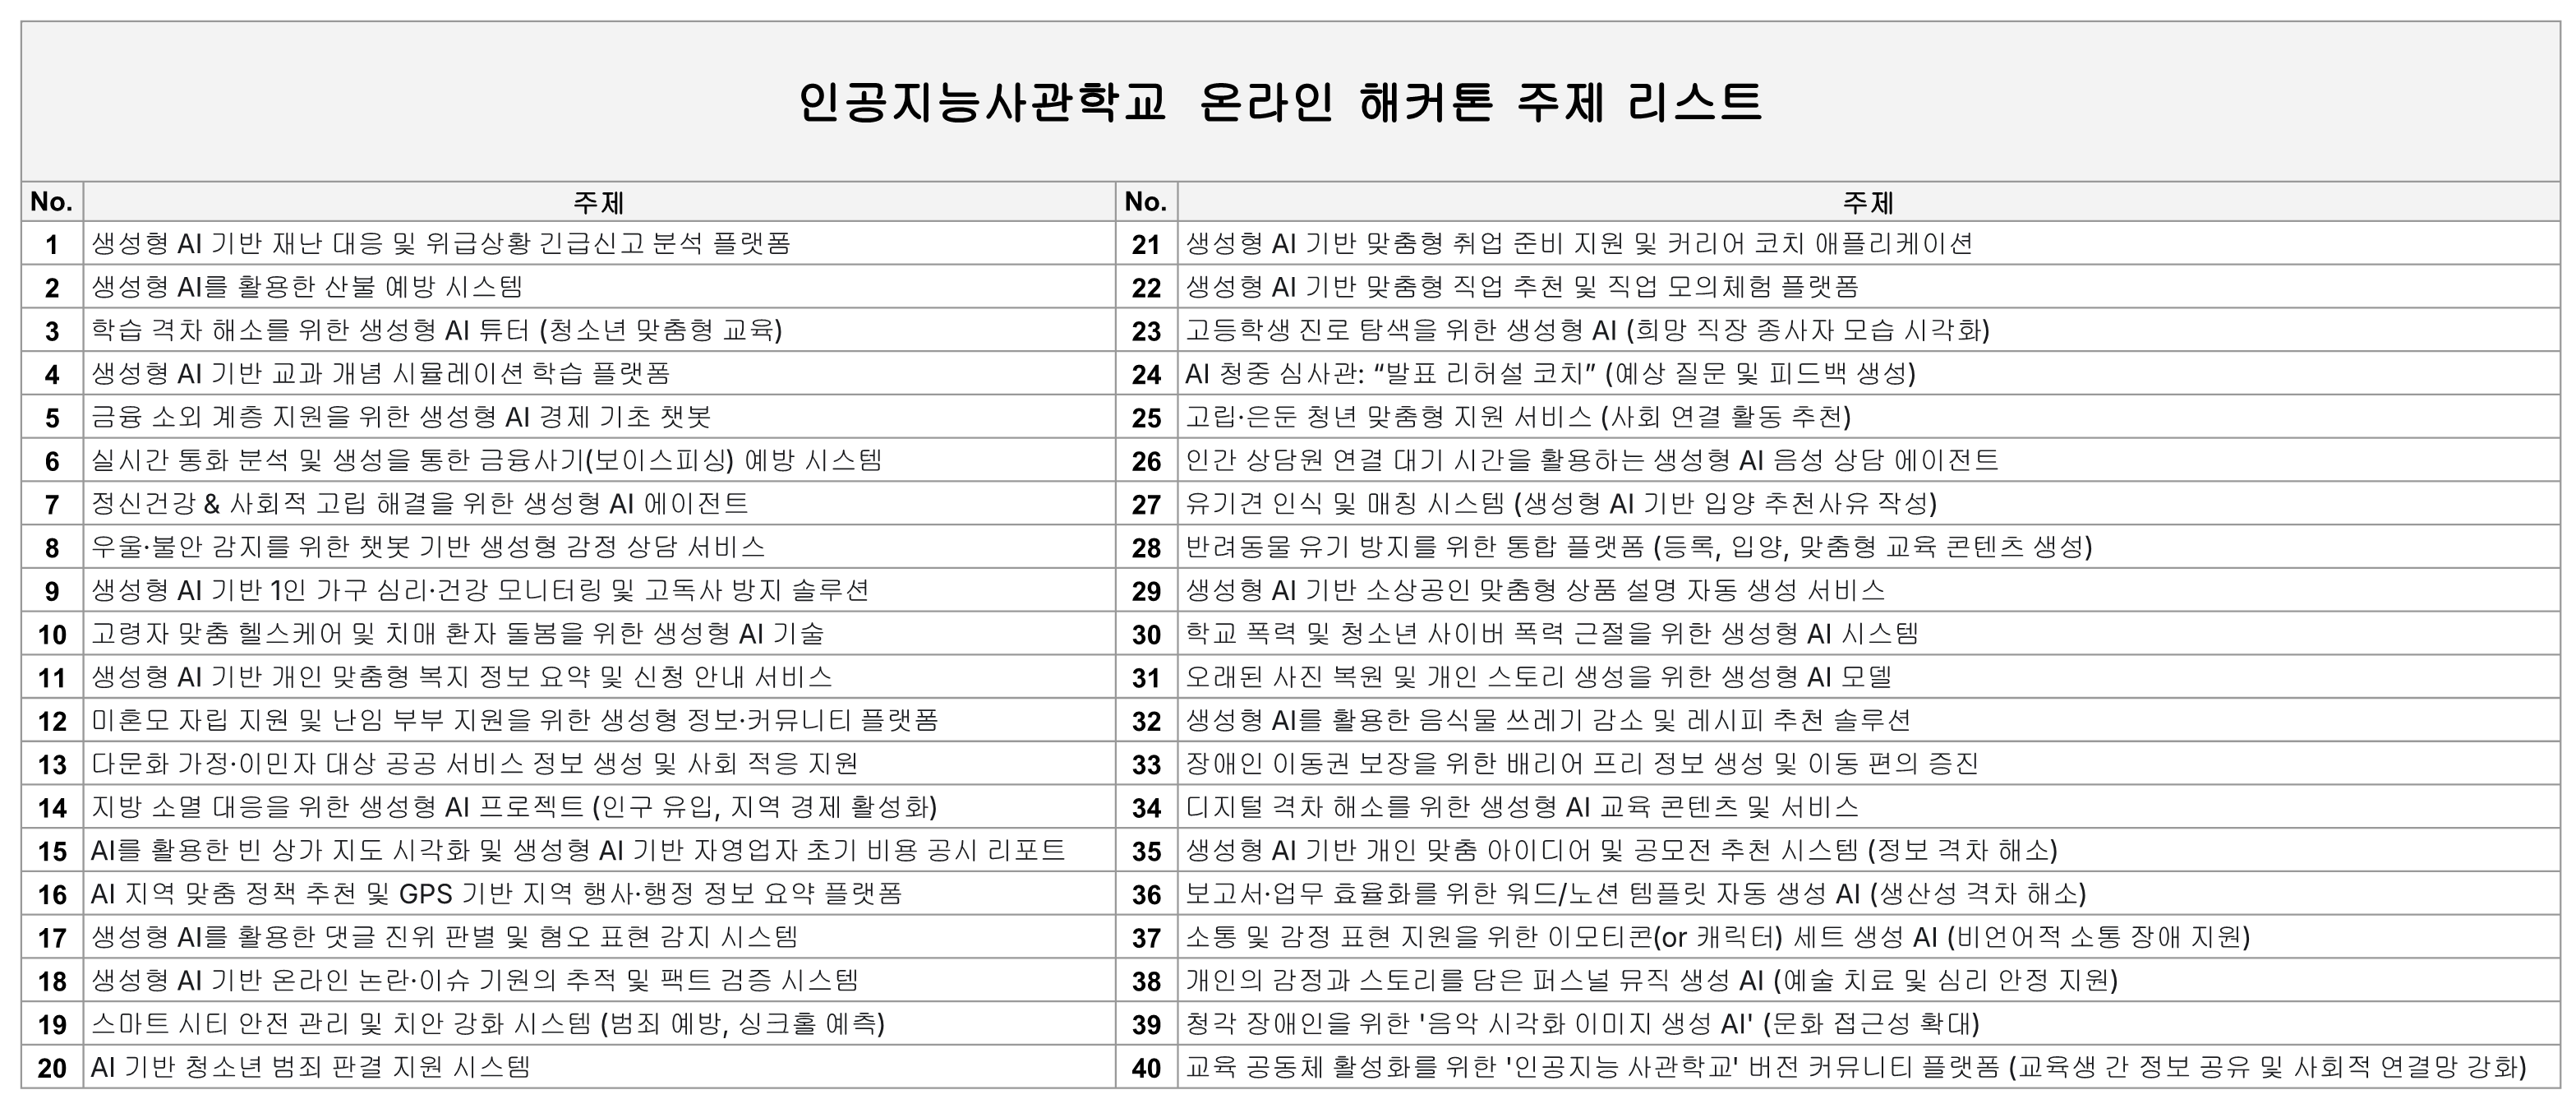

In [74]:
# 작업 준비
import numpy as np
import torch
import matplotlib.pyplot as plt

from torch.utils import data
from torchvision import datasets, transforms, utils
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F

# 상수값 설정
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
BATCH_SIZE = 64
EPOCHS = 10

In [8]:
# 데이터 수정 (노이즈 삽입)
# 1. 데이터 준비
transform=transforms.Compose([
    #transforms.RandomHorizontalFlip(),#데이터 증강(노이즈삽입)
    transforms.ToTensor(),#입력 데이터 정리
    transforms.Normalize((0.2860,),(0.3530,))
])#데이터 사용 방식 내용 결정
tr_ds_loader=torch.utils.data.DataLoader(
    datasets.FashionMNIST('./data/',
        train=True,
        download=False,
        transform=transform
    ),
    batch_size=BATCH_SIZE,
    shuffle=True
)
tt_ds_loader=torch.utils.data.DataLoader(
    datasets.FashionMNIST('./data/',
        train=False,
        transform=transform
    ),
    batch_size=BATCH_SIZE,
    shuffle=True
)

In [9]:
class Model(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(1,10, kernel_size=5)
        self.conv2 = nn.Conv2d(10,20, kernel_size=5)
        self.conv2_drop = nn.Dropout2d()
        self.fc1 = nn.Linear(320, 50)
        self.fc2 = nn.Linear(50, 10)

    def forward(self,x):
        x = F.max_pool2d(self.conv1(x), 2)
        x = F.max_pool2d(self.conv2_drop(self.conv2(x)), 2)
        x = x.view(-1, 320)
        x = F.relu(self.fc1(x))
        x = F.dropout(x, training=self.training)
        x = self.fc2(x)
        return x

In [10]:
# 학습함수 설계
def train(m, tr_ds_loader, opt, epoch):
    m.train()
    for i, (data, target) in enumerate(tr_ds_loader):
        data, target = data.to(DEVICE), target.to(DEVICE)
        opt.zero_grad()
        output = m(data)
        loss = F.cross_entropy(output, target)
        loss.backward()
        opt.step()

        if i % 100 == 0:
            print(f"train epoch{epoch} {i*len(data)}/{len(tr_ds_loader.dataset)}({i*100/len(tr_ds_loader)}%) loss: {loss.item()}")

In [11]:
@torch.no_grad() # 서식
def evaluate(m, tt_ds_loader):
    m.eval()
    test_loss = 0
    correct = 0
    for data, target in tt_ds_loader:
        data, target = data.to(DEVICE), target.to(DEVICE)
        output = m(data)
        test_loss += F.cross_entropy(output, target, reduction='sum').item()
        pred = output.max(1, keepdim=True)[1]
        correct += pred.eq(target.view_as(pred)).sum().item() # 데이터 구조를 일치하도록 만들기 위해 하는 작업
    test_loss /= len(tt_ds_loader.dataset)
    test_accuracy = correct/len(tt_ds_loader.dataset)*100.
    return test_loss, test_accuracy

In [13]:
m = Model().to(DEVICE)
opt = optim.SGD(m.parameters(), lr=1e-2, momentum=0.5)

In [15]:
for i in range(1, EPOCHS+1):
    train(m, tr_ds_loader, opt, i)
    test_loss, test_acc = evaluate(m, tt_ds_loader)
    print(f'epochs: {i}\ttest_loss: {test_loss}\ttest_accuracy: {test_acc}')

train epoch1 0/60000(0.0%) loss: 2.331251859664917
train epoch1 6400/60000(10.660980810234541%) loss: 1.326579213142395
train epoch1 12800/60000(21.321961620469082%) loss: 1.1017839908599854
train epoch1 19200/60000(31.982942430703623%) loss: 0.9191797375679016
train epoch1 25600/60000(42.643923240938165%) loss: 0.8927801847457886
train epoch1 32000/60000(53.304904051172706%) loss: 0.8360579013824463
train epoch1 38400/60000(63.96588486140725%) loss: 0.9215705990791321
train epoch1 44800/60000(74.6268656716418%) loss: 0.77944016456604
train epoch1 51200/60000(85.28784648187633%) loss: 0.7847667336463928
train epoch1 57600/60000(95.94882729211088%) loss: 1.1863075494766235
epochs: 1	test_loss: 0.6378396646976471	test_accuracy: 76.66
train epoch2 0/60000(0.0%) loss: 0.7735168933868408
train epoch2 6400/60000(10.660980810234541%) loss: 0.9257378578186035
train epoch2 12800/60000(21.321961620469082%) loss: 0.9542005658149719
train epoch2 19200/60000(31.982942430703623%) loss: 0.69086956977

In [ ]:
이미지 전처리시에 이미지의 크기가 뒤죽박죽이면 어느정도의 사이즈로 조절하는 것이 좋을까?
사용하려는 모델이 있다면 그 모델에 맞추는 게 좋을까?
아니면 독자적인 사이즈를 구성하여 이미지를 조절하는 것이 좋을까?

# ResNet

In [17]:
m = Model().to(DEVICE)
opt = optim.SGD(m.parameters(), lr=1e-2, momentum=0.5)
# 아래가 스케줄임
scheduler = optim.lr_scheduler.StepLR(opt, step_size=10, gamma=0.1) # 해당 코드는 가급적 에폭당으로 카운팅할 것, gamma는 어느정도의 비율을 줄일 것인가를 설정

In [18]:
for i in range(1, EPOCHS+1):
    train(m, tr_ds_loader, opt, i)
    scheduler.step()
    test_loss, test_acc = evaluate(m, tt_ds_loader)
    print(f'epochs: {i}\ttest_loss: {test_loss}\ttest_accuracy: {test_acc} lr_scheduler: {scheduler.get_last_lr()}')

train epoch1 0/60000(0.0%) loss: 2.3191168308258057
train epoch1 6400/60000(10.660980810234541%) loss: 1.3376493453979492
train epoch1 12800/60000(21.321961620469082%) loss: 1.0756216049194336
train epoch1 19200/60000(31.982942430703623%) loss: 1.0133514404296875
train epoch1 25600/60000(42.643923240938165%) loss: 1.0950672626495361
train epoch1 32000/60000(53.304904051172706%) loss: 1.0125346183776855
train epoch1 38400/60000(63.96588486140725%) loss: 0.7234077453613281
train epoch1 44800/60000(74.6268656716418%) loss: 0.791079044342041
train epoch1 51200/60000(85.28784648187633%) loss: 0.9427127242088318
train epoch1 57600/60000(95.94882729211088%) loss: 0.7613769769668579
epochs: 1	test_loss: 0.6612677226066589	test_accuracy: 74.86 lr_scheduler: [0.01]
train epoch2 0/60000(0.0%) loss: 1.0252574682235718
train epoch2 6400/60000(10.660980810234541%) loss: 0.8142894506454468
train epoch2 12800/60000(21.321961620469082%) loss: 0.8981958031654358
train epoch2 19200/60000(31.9829424307036

In [21]:
ck_tr = transforms.Compose([transforms.ToTensor()])
tr_ds = datasets.CIFAR10(root='./data/', train=True, download=True, transform=ck_tr)
tr_ds_loader = torch.utils.data.DataLoader(tr_ds, batch_size=50000, shuffle=False) # 평균과 분산을 보기 위함

100%|██████████| 170M/170M [00:19<00:00, 8.91MB/s] 


In [23]:
ck_data = iter(tr_ds_loader)
data, _ = next(ck_data)

In [26]:
data.shape

torch.Size([50000, 3, 32, 32])

In [25]:
data.mean(dim=[0,2,3]), data.std(dim=[0,2,3])

(tensor([0.4914, 0.4822, 0.4465]), tensor([0.2470, 0.2435, 0.2616]))

In [27]:
# 상수값 설정
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
BATCH_SIZE = 64
EPOCHS = 10

In [28]:
# 데이터 수정 (노이즈 삽입)
# 1. 데이터 준비
transform=transforms.Compose([
    #transforms.RandomHorizontalFlip(),#데이터 증강(노이즈삽입)
    transforms.ToTensor(),#입력 데이터 정리
    transforms.Normalize((0.4914, 0.4822, 0.4465),(0.2470, 0.2435, 0.2616))
])#데이터 사용 방식 내용 결정
tr_ds_loader=torch.utils.data.DataLoader(
    datasets.CIFAR10('./data/',
        train=True,
        download=False,
        transform=transform
    ),
    batch_size=BATCH_SIZE,
    shuffle=True
)
tt_ds_loader=torch.utils.data.DataLoader(
    datasets.CIFAR10('./data/',
        train=False,
        transform=transform
    ),
    batch_size=BATCH_SIZE,
    shuffle=True
)

In [81]:
class BasicBlock(nn.Module):
    def __init__(self, in_planes, planes, stride=1):
        super().__init__()
        self.conv1 = nn.Conv2d(in_planes, planes, kernel_size=3, stride=stride, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(planes)
        self.conv2 = nn.Conv2d(planes, planes, kernel_size=3, stride=1, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(planes)

        self.shortcut = nn.Sequential()
        if stride != 1 or in_planes != planes:
            self.shortcut = nn.Sequential(
                nn.Conv2d(in_planes, planes, kernel_size=3, stride=stride, padding=1, bias=False),
                nn.BatchNorm2d(planes)
            )

    def forward(self, x):
        out = F.relu(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))
        out += self.shortcut(x)
        out = F.relu(out)
        return out

class Resnet(nn.Module):
    def __init__(self, class_n):
        super().__init__()
        self.in_planes = 16
        self.conv1 = nn.Conv2d(3, 16, kernel_size=3, stride=1, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(16)
        self.l1 = self._make_l(16, 2, 1)
        self.l2 = self._make_l(32, 2, 2)
        self.l3 = self._make_l(64, 2, 2)
        self.out_l = nn.Linear(64, class_n)

    def _make_l(self, planes, num_block, stride):
        strides = [stride] + [1]*(num_block-1)
        l = []
        for stride in strides:
            l.append(BasicBlock(self.in_planes, planes, stride))
            self.in_planes = planes
        
        return nn.Sequential(*l)
    
    def forward(self, x):
        x = F.relu(self.bn1(self.conv1(x))) # 스템
        
        x = self.l1(x) # 몸체
        x = self.l2(x)
        x = self.l3(x)

        x = F.avg_pool2d(x, 8) # 분류기
        x = x.view(x.size(0), -1)
        out = self.out_l(x)
        return out

In [82]:
m = Resnet(10).to(DEVICE)
opt = optim.SGD(m.parameters(), lr=0.1, momentum=0.9, weight_decay=0.0005)
scheduler = optim.lr_scheduler.StepLR(optimizer=opt, step_size=3, gamma=0.1) # stepsize는 통상 전체 epoch의 3분의 1정도라고 함

In [83]:
# 학습함수 설계
def train(m, tr_ds_loader, opt, epoch):
    m.train()
    for i, (data, target) in enumerate(tr_ds_loader):
        data, target = data.to(DEVICE), target.to(DEVICE)
        opt.zero_grad()
        output = m(data)
        loss = F.cross_entropy(output, target)
        loss.backward()
        opt.step()

        if i % 100 == 0:
            print(f"train epoch{epoch} {i*len(data)}/{len(tr_ds_loader.dataset)}({i*100/len(tr_ds_loader)}%) loss: {loss.item()}")

In [84]:
@torch.no_grad() # 서식
def evaluate(m, tt_ds_loader):
    m.eval()
    test_loss = 0
    correct = 0
    for data, target in tt_ds_loader:
        data, target = data.to(DEVICE), target.to(DEVICE)
        output = m(data)
        test_loss += F.cross_entropy(output, target, reduction='sum').item()
        pred = output.max(1, keepdim=True)[1]
        correct += pred.eq(target.view_as(pred)).sum().item() # 데이터 구조를 일치하도록 만들기 위해 하는 작업
    test_loss /= len(tt_ds_loader.dataset)
    test_accuracy = correct/len(tt_ds_loader.dataset)*100.
    return test_loss, test_accuracy

In [85]:
for i in range(1, EPOCHS+1):
    train(m, tr_ds_loader, opt, i)
    scheduler.step()
    test_loss, test_acc = evaluate(m, tt_ds_loader)
    print(f'epochs: {i}\ttest_loss: {test_loss}\ttest_accuracy: {test_acc} lr_scheduler: {scheduler.get_last_lr()}')

train epoch1 0/50000(0.0%) loss: 2.361713171005249
train epoch1 6400/50000(12.787723785166241%) loss: 1.7072488069534302
train epoch1 12800/50000(25.575447570332482%) loss: 1.8227083683013916
train epoch1 19200/50000(38.36317135549872%) loss: 1.5550246238708496
train epoch1 25600/50000(51.150895140664964%) loss: 1.5074241161346436
train epoch1 32000/50000(63.9386189258312%) loss: 1.0648351907730103
train epoch1 38400/50000(76.72634271099744%) loss: 1.289679765701294
train epoch1 44800/50000(89.51406649616368%) loss: 0.9922031164169312
epochs: 1	test_loss: 1.513531844329834	test_accuracy: 48.15 lr_scheduler: [0.1]
train epoch2 0/50000(0.0%) loss: 1.2051153182983398
train epoch2 6400/50000(12.787723785166241%) loss: 1.0315743684768677
train epoch2 12800/50000(25.575447570332482%) loss: 1.0263676643371582
train epoch2 19200/50000(38.36317135549872%) loss: 1.044931173324585
train epoch2 25600/50000(51.150895140664964%) loss: 0.8485078811645508
train epoch2 32000/50000(63.9386189258312%) lo

# GAN해보기(Pytorch)

https://tutorials.pytorch.kr/beginner/dcgan_faces_tutorial.html

In [16]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils import data
from torchvision import datasets, transforms, utils